In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\Salary Data.csv")

In [3]:
df=data.copy()

In [4]:
df.dropna(inplace=True)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  324 non-null    float64
 1   Gender               324 non-null    object 
 2   Education Level      324 non-null    object 
 3   Job Title            324 non-null    object 
 4   Years of Experience  324 non-null    float64
 5   Salary               324 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [7]:
df["Salary"]=df["Salary"].astype(int)

In [8]:
df.head(4)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000
1,28.0,Female,Master's,Data Analyst,3.0,65000
2,45.0,Male,PhD,Senior Manager,15.0,150000
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000


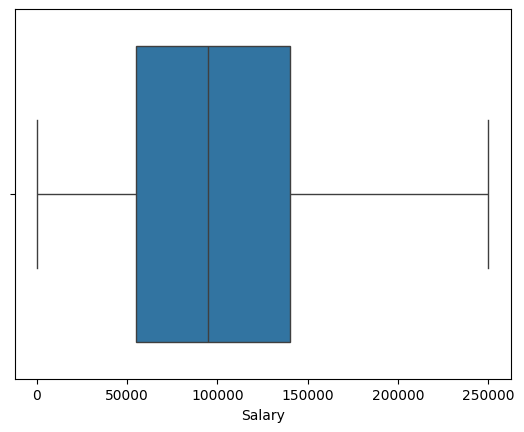

In [9]:
sns.boxplot(x=df["Salary"],data=df)
plt.show()

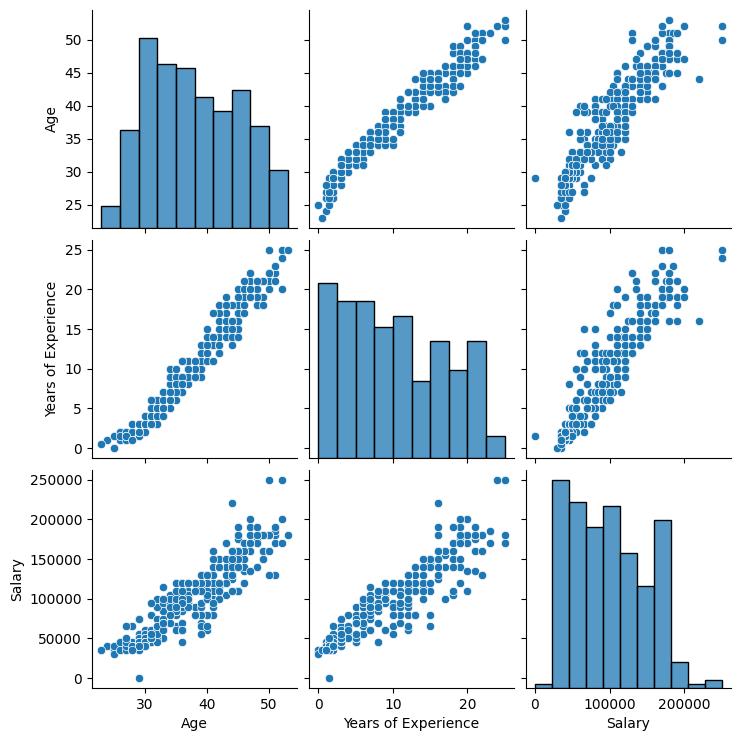

In [10]:
sns.pairplot(data=df)
plt.show()

In [11]:
from mlxtend.plotting import plot_decision_regions

In [12]:
x=df[["Age","Years of Experience"]]
y=df["Salary"]

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
lg=LinearRegression()
lg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
lg.score(x_test,y_test),lg.score(x_train,y_train)

(0.8525276864529965, 0.8581548072875048)

In [17]:
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [18]:
np.sqrt(mean_squared_error(y_test,lg.predict(x_test)))

np.float64(16694.048591734707)

In [19]:
mean_absolute_error(y_test,lg.predict(x_test))

11931.062804398658

In [20]:
from sklearn.tree import DecisionTreeRegressor
dc=DecisionTreeRegressor(max_depth=5,splitter='best',criterion='squared_error')

In [21]:
dc.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [22]:
dc.score(x_test,y_test)

0.8379543991154361

In [23]:
from sklearn.svm import SVR
svm=SVR(kernel='linear')
svm.fit(x_train,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [24]:
svm.score(x_test,y_test)

0.5631802254396492

In [25]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000
1,28.0,Female,Master's,Data Analyst,3.0,65000
2,45.0,Male,PhD,Senior Manager,15.0,150000
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000
4,52.0,Male,Master's,Director,20.0,200000
...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000


In [37]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
one=OneHotEncoder(sparse_output=False)

In [27]:
en=pd.DataFrame(one.fit_transform(df[["Gender"]]),columns=one.get_feature_names_out())

In [28]:
df.reset_index(inplace=True)

In [29]:
en

,Gender_Female,Gender_Male
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0
...,...,...
319,1.0,0.0
320,0.0,1.0
321,1.0,0.0
322,0.0,1.0


In [30]:
df=pd.concat([df, en], axis=1)

In [41]:
df

,index,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Gender_Female,Gender_Male,Education Level1
0,0,32.0,Male,Bachelor's,Software Engineer,5.0,90000,0.0,1.0,0.0
1,1,28.0,Female,Master's,Data Analyst,3.0,65000,1.0,0.0,1.0
2,2,45.0,Male,PhD,Senior Manager,15.0,150000,0.0,1.0,2.0
3,3,36.0,Female,Bachelor's,Sales Associate,7.0,60000,1.0,0.0,0.0
4,4,52.0,Male,Master's,Director,20.0,200000,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
319,348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000,1.0,0.0,0.0
320,349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000,0.0,1.0,0.0
321,350,44.0,Female,PhD,Senior Data Scientist,16.0,160000,1.0,0.0,2.0
322,351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000,0.0,1.0,0.0


In [32]:
df["Education Level"].unique()

array(["Bachelor's", "Master's", 'PhD'], dtype=object)

In [35]:
list=[["Bachelor's", "Master's", 'PhD']]

In [38]:
lb=OrdinalEncoder(categories=list)

In [40]:
df["Education Level1"]=lb.fit_transform(df[["Education Level"]])

In [46]:
df.drop(columns="index",inplace=True)

In [47]:
df.head(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Gender_Female,Gender_Male,Education Level1
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000,0.0,1.0,0.0
1,28.0,Female,Master's,Data Analyst,3.0,65000,1.0,0.0,1.0
2,45.0,Male,PhD,Senior Manager,15.0,150000,0.0,1.0,2.0


In [48]:
X=df[["Age","Gender_Female","Gender_Male","Education Level1","Years of Experience"]]
Y=df["Salary"]

In [49]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [50]:
lg1=LinearRegression()
lg1.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
lg1.score(X_test,Y_test)

0.8913410224920045

In [53]:
np.sqrt(mean_squared_error(Y_test,lg1.predict(X_test)))

np.float64(14329.770451721992)

In [55]:
dc1=DecisionTreeRegressor()
dc1.fit(X_train,Y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [56]:
dc1.score(X_test,Y_test)

0.8385113969480574

In [60]:
scm1=SVR(kernel='linear')
scm1.fit(X_train,Y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [61]:
scm1.score(X_test,Y_test)

0.5646589036977415

In [62]:
from sklearn.neighbors import KNeighborsRegressor
kn=KNeighborsRegressor()

In [63]:
kn.fit(X_train,Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [64]:
kn.score(X_test,Y_test)

0.8584891796451809